In [1]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *

In [2]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

In [3]:
def I(pi):
    return -math.log(pi, 2)

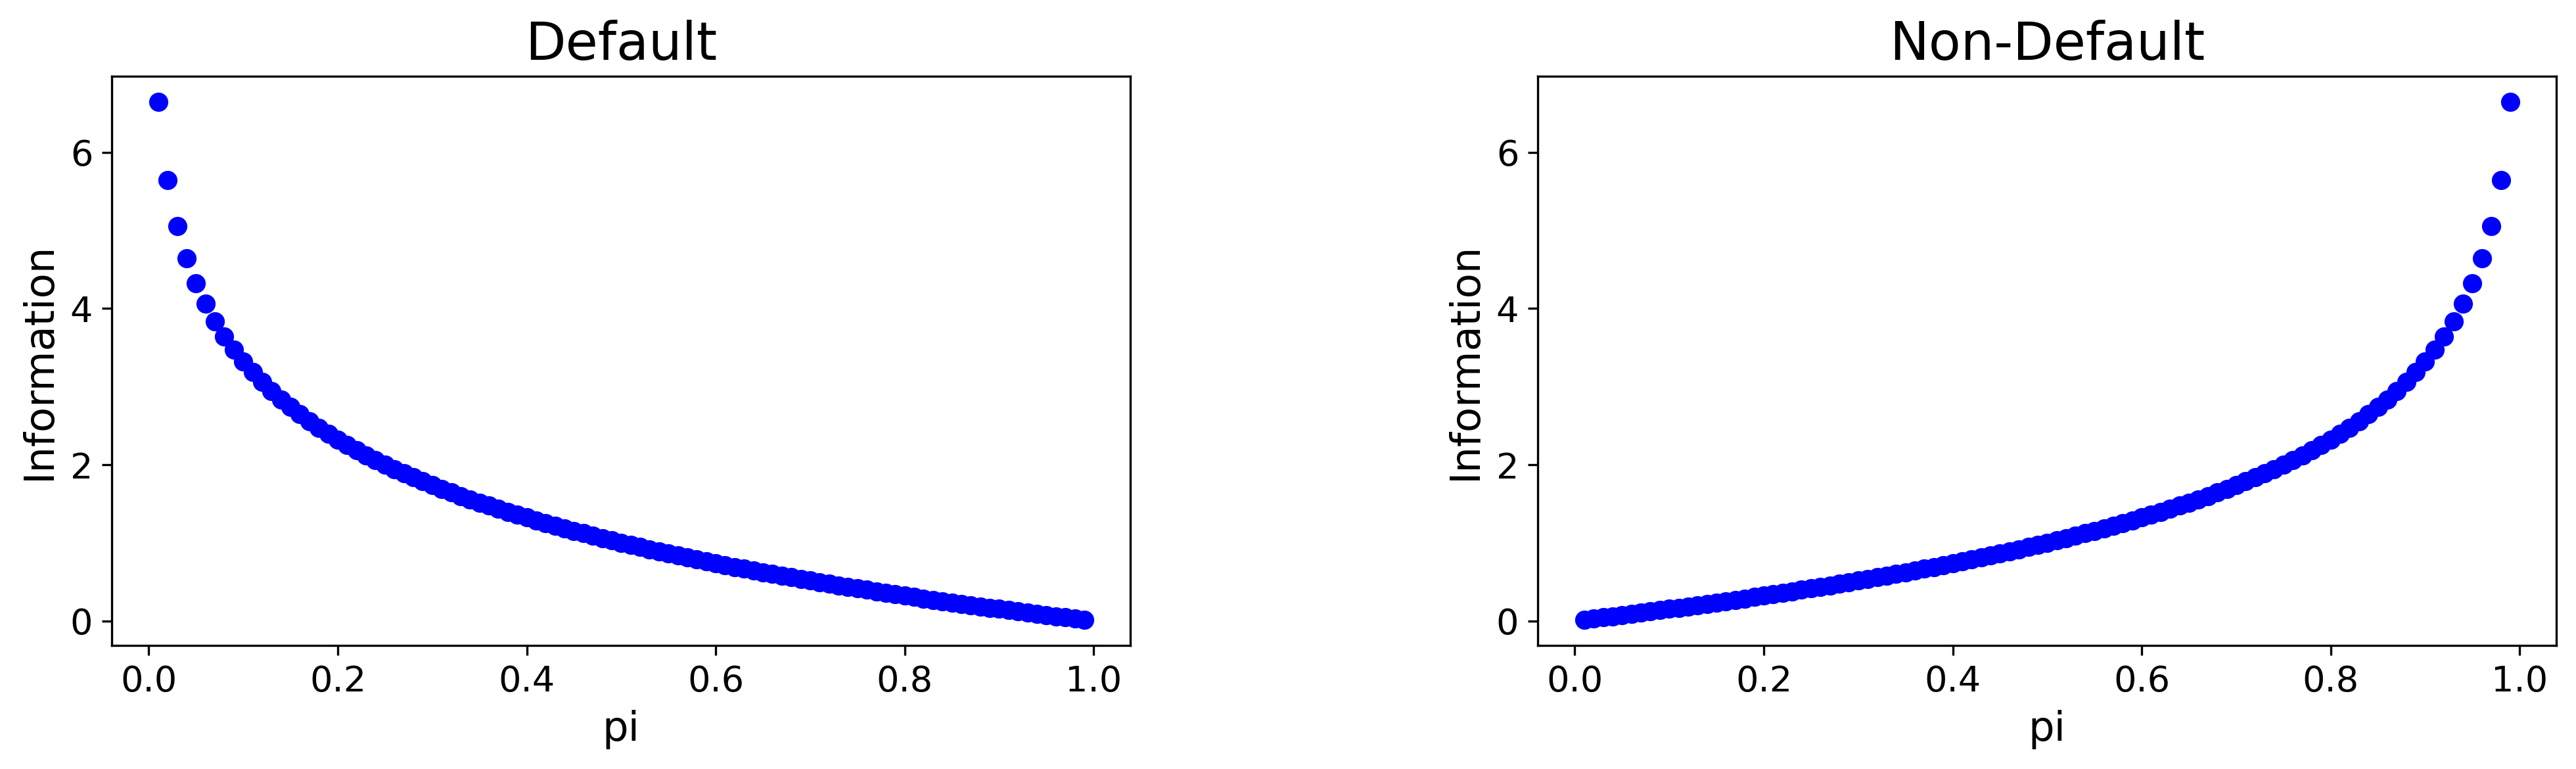

In [4]:
plt.subplots_adjust(hspace=0.4, wspace=0.4)

plt.subplot(221)
plt.title('Default')
for i in range(1, 100, 1):
    pi = i/100
    plt.xlabel('pi', fontsize=15)
    plt.ylabel('Information', fontsize=15)
    plt.tick_params(axis='both', labelsize=13)
    plt.plot(pi, I(pi), color='blue', marker='o')

plt.subplot(222)
plt.title('Non-Default')
for i in range(1, 100, 1):
    pi = i/100
    plt.xlabel('pi', fontsize=15)
    plt.ylabel('Information', fontsize=15)
    plt.tick_params(axis='both', labelsize=13)
    plt.plot(pi, I(1-pi), color='blue', marker='o')

plt.show()

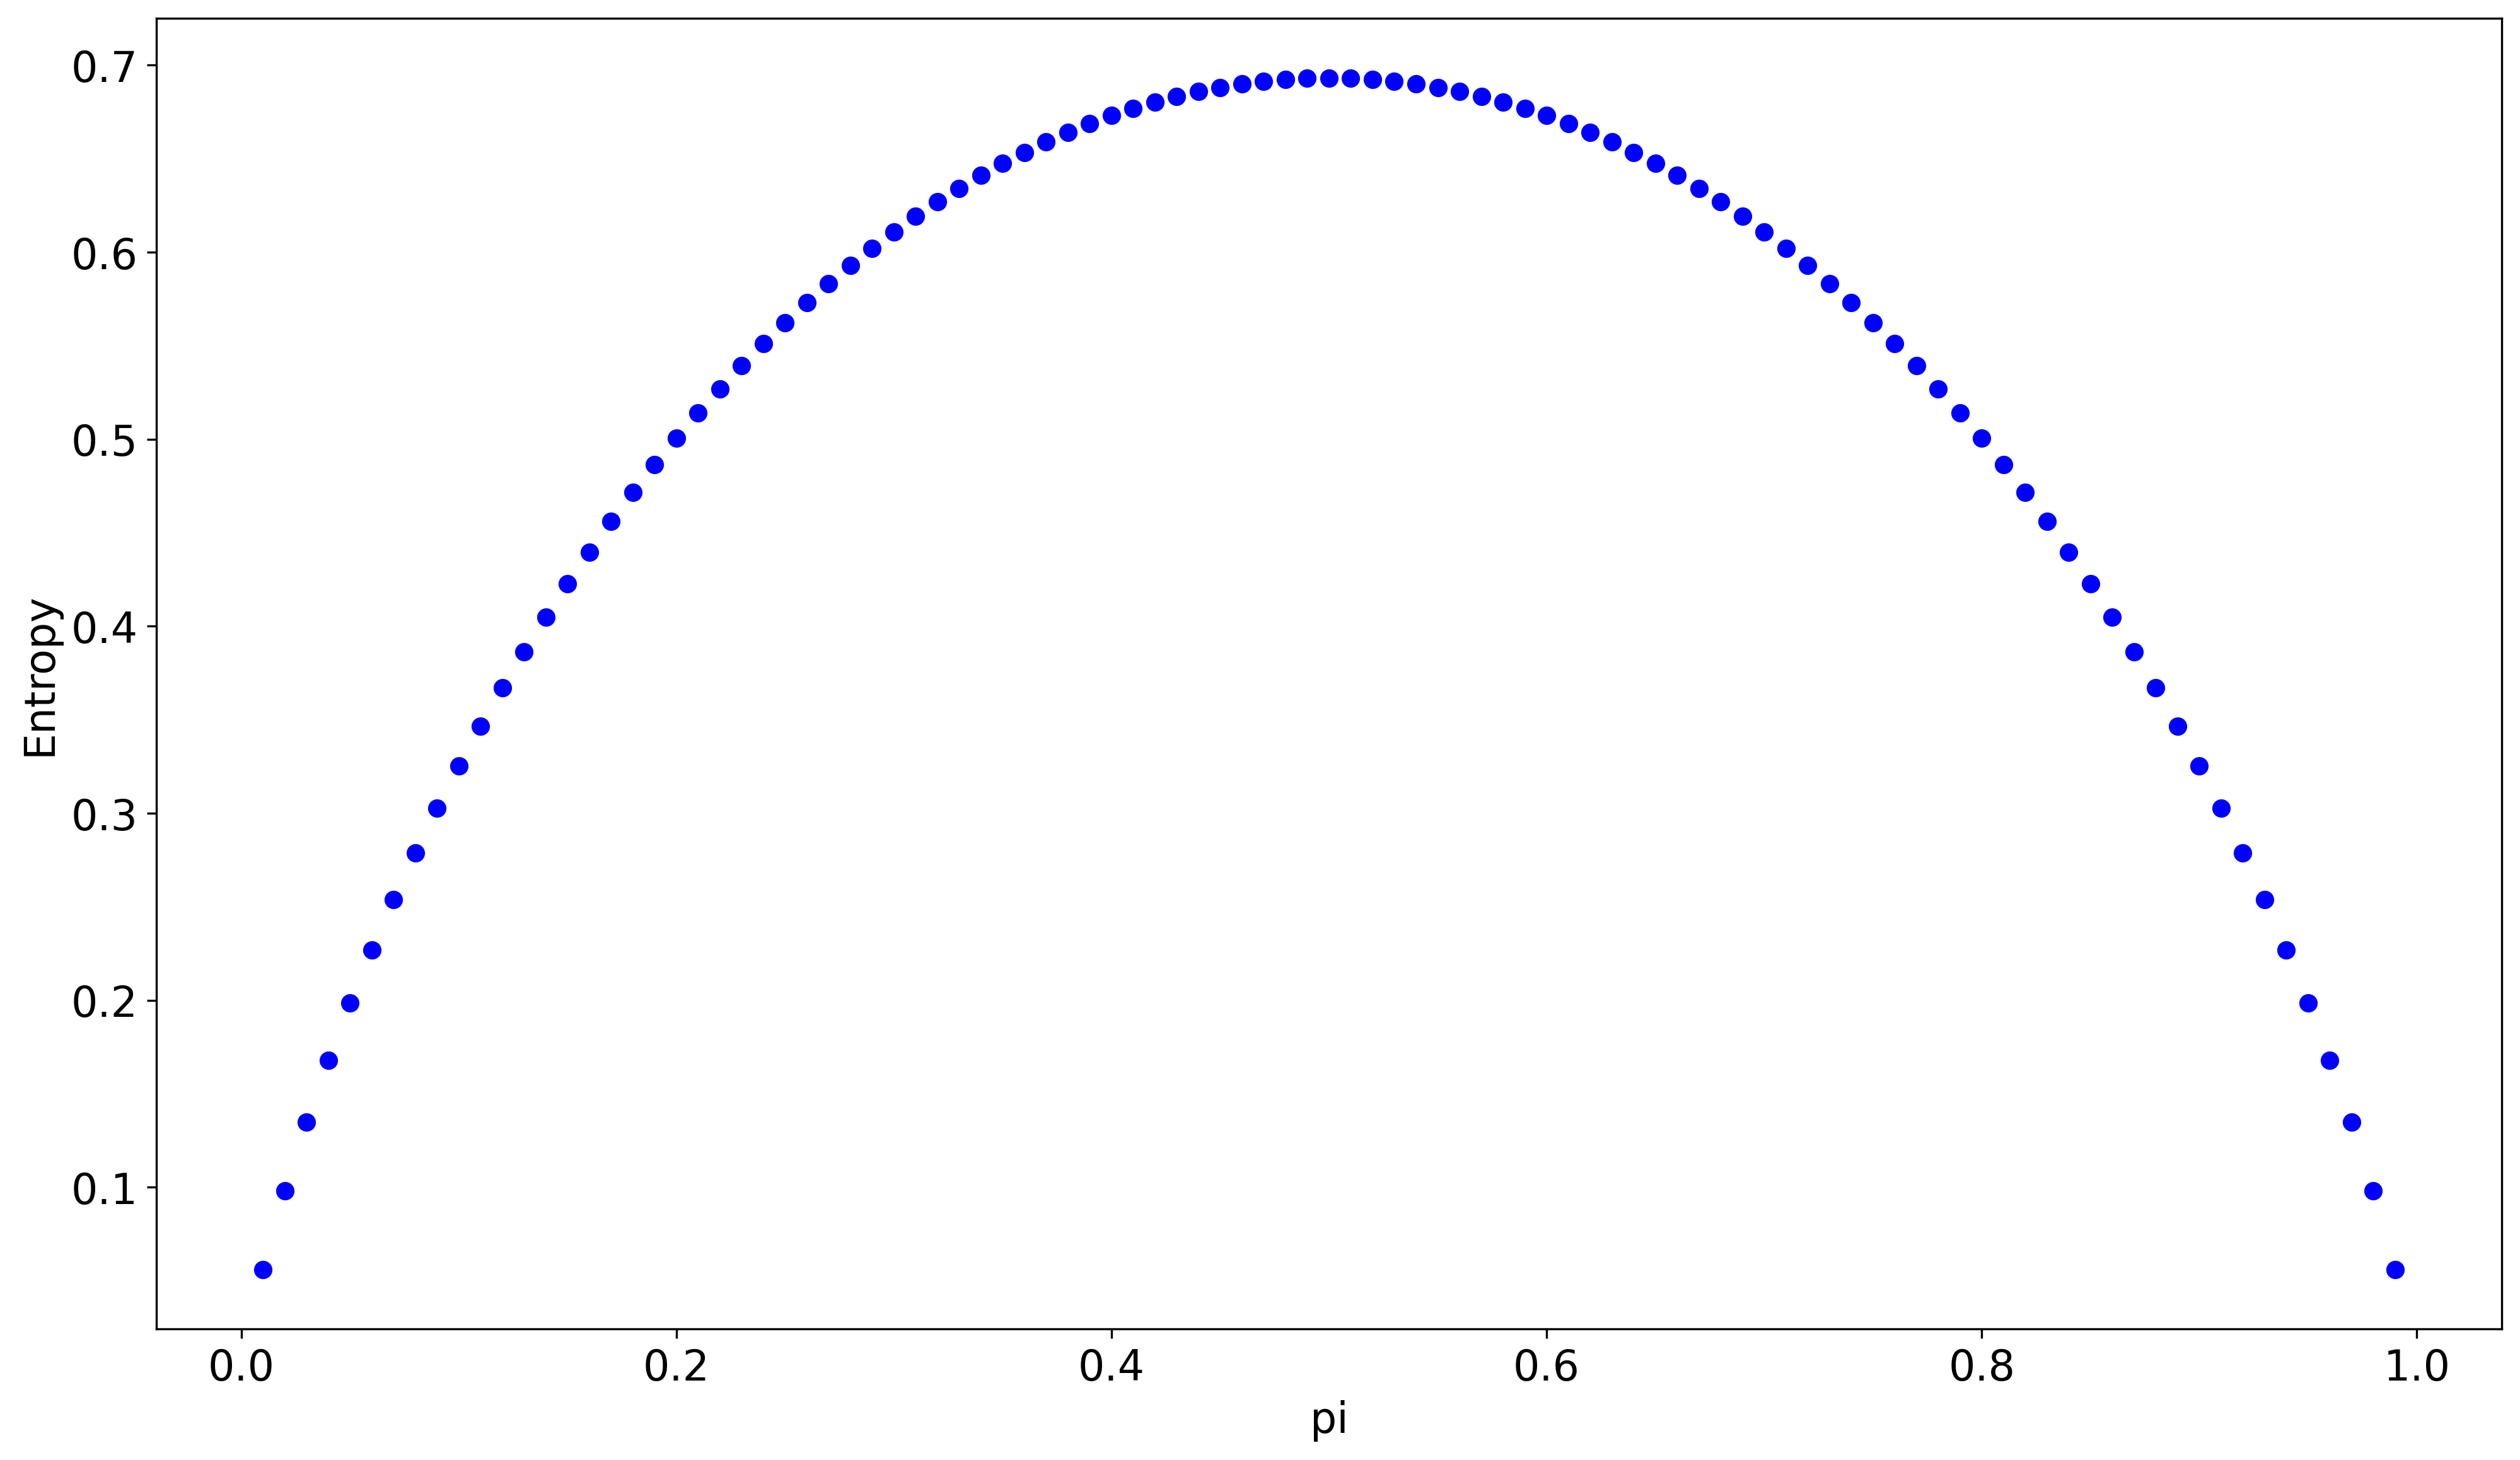

In [5]:
def Entropy(pi):
    return - pi * math.log(pi) - (1-pi) * math.log(1-pi)

for i in range(1, 100, 1):
    pi = i/100
    plt.xlabel('pi')
    plt.ylabel('Entropy')
    plt.plot(pi, Entropy(pi), color='blue', marker='o')
    

In [6]:
def CrossEntropy(pi, d):
    if d == 1:
        return -math.log(pi)
    else:
        return -math.log(1 - pi)

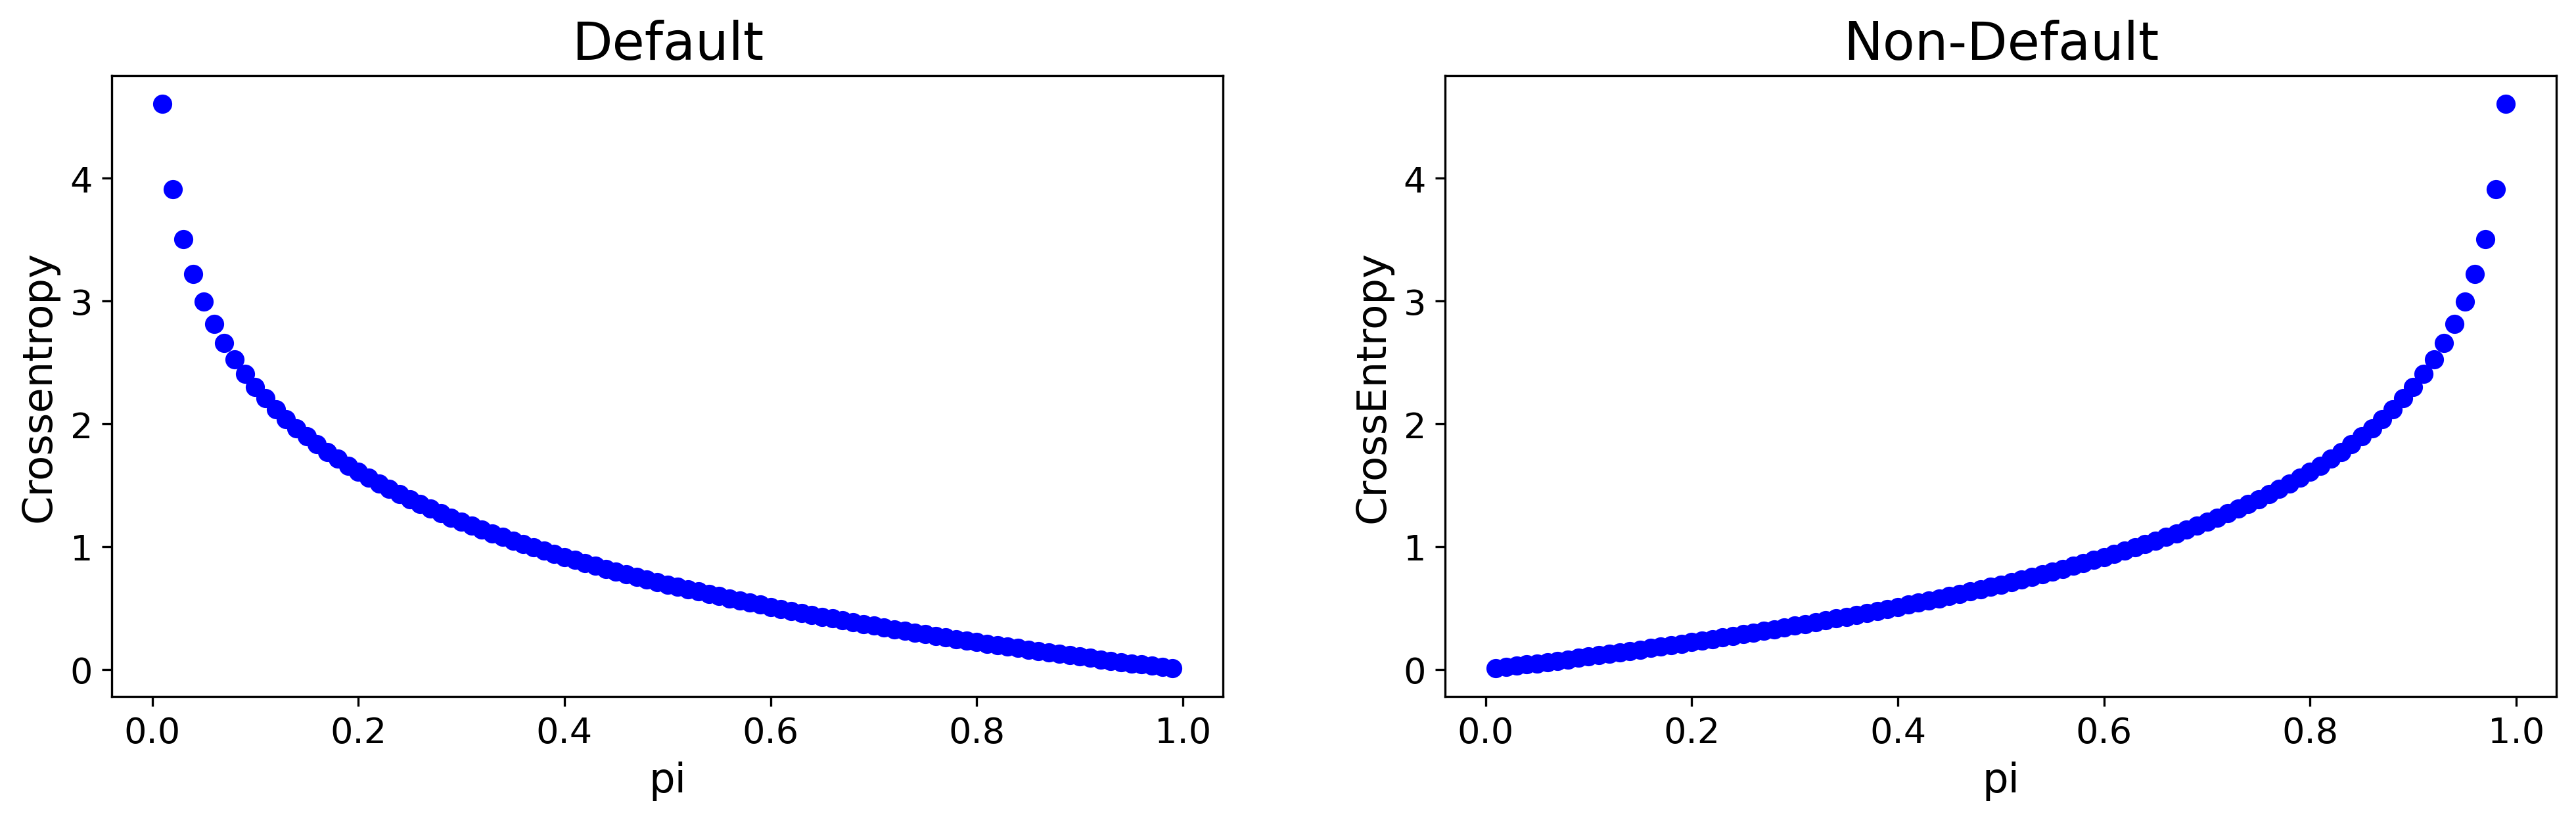

In [7]:
plt.subplot(221)
plt.title('Default')
for i in range(1, 100, 1):
    d = 1
    pi = i/100
    plt.xlabel('pi', fontsize=15)
    plt.ylabel('Crossentropy', fontsize=15)
    plt.tick_params(axis='both', labelsize=13)
    plt.plot(pi, CrossEntropy(pi, d), color='blue', marker='o')

plt.subplot(222)
plt.title('Non-Default')
for i in range(1, 100, 1):
    d = 0 
    pi = i/100
    plt.xlabel('pi', fontsize=15)
    plt.ylabel('CrossEntropy', fontsize=15)
    plt.tick_params(axis='both', labelsize=13)
    plt.plot(pi, CrossEntropy(pi, d), color='blue', marker='o')

plt.show()

z: -1.6829673572159562e-10
function: 2.949166103138755e-20
derivative: -3.4346272596244006e-10


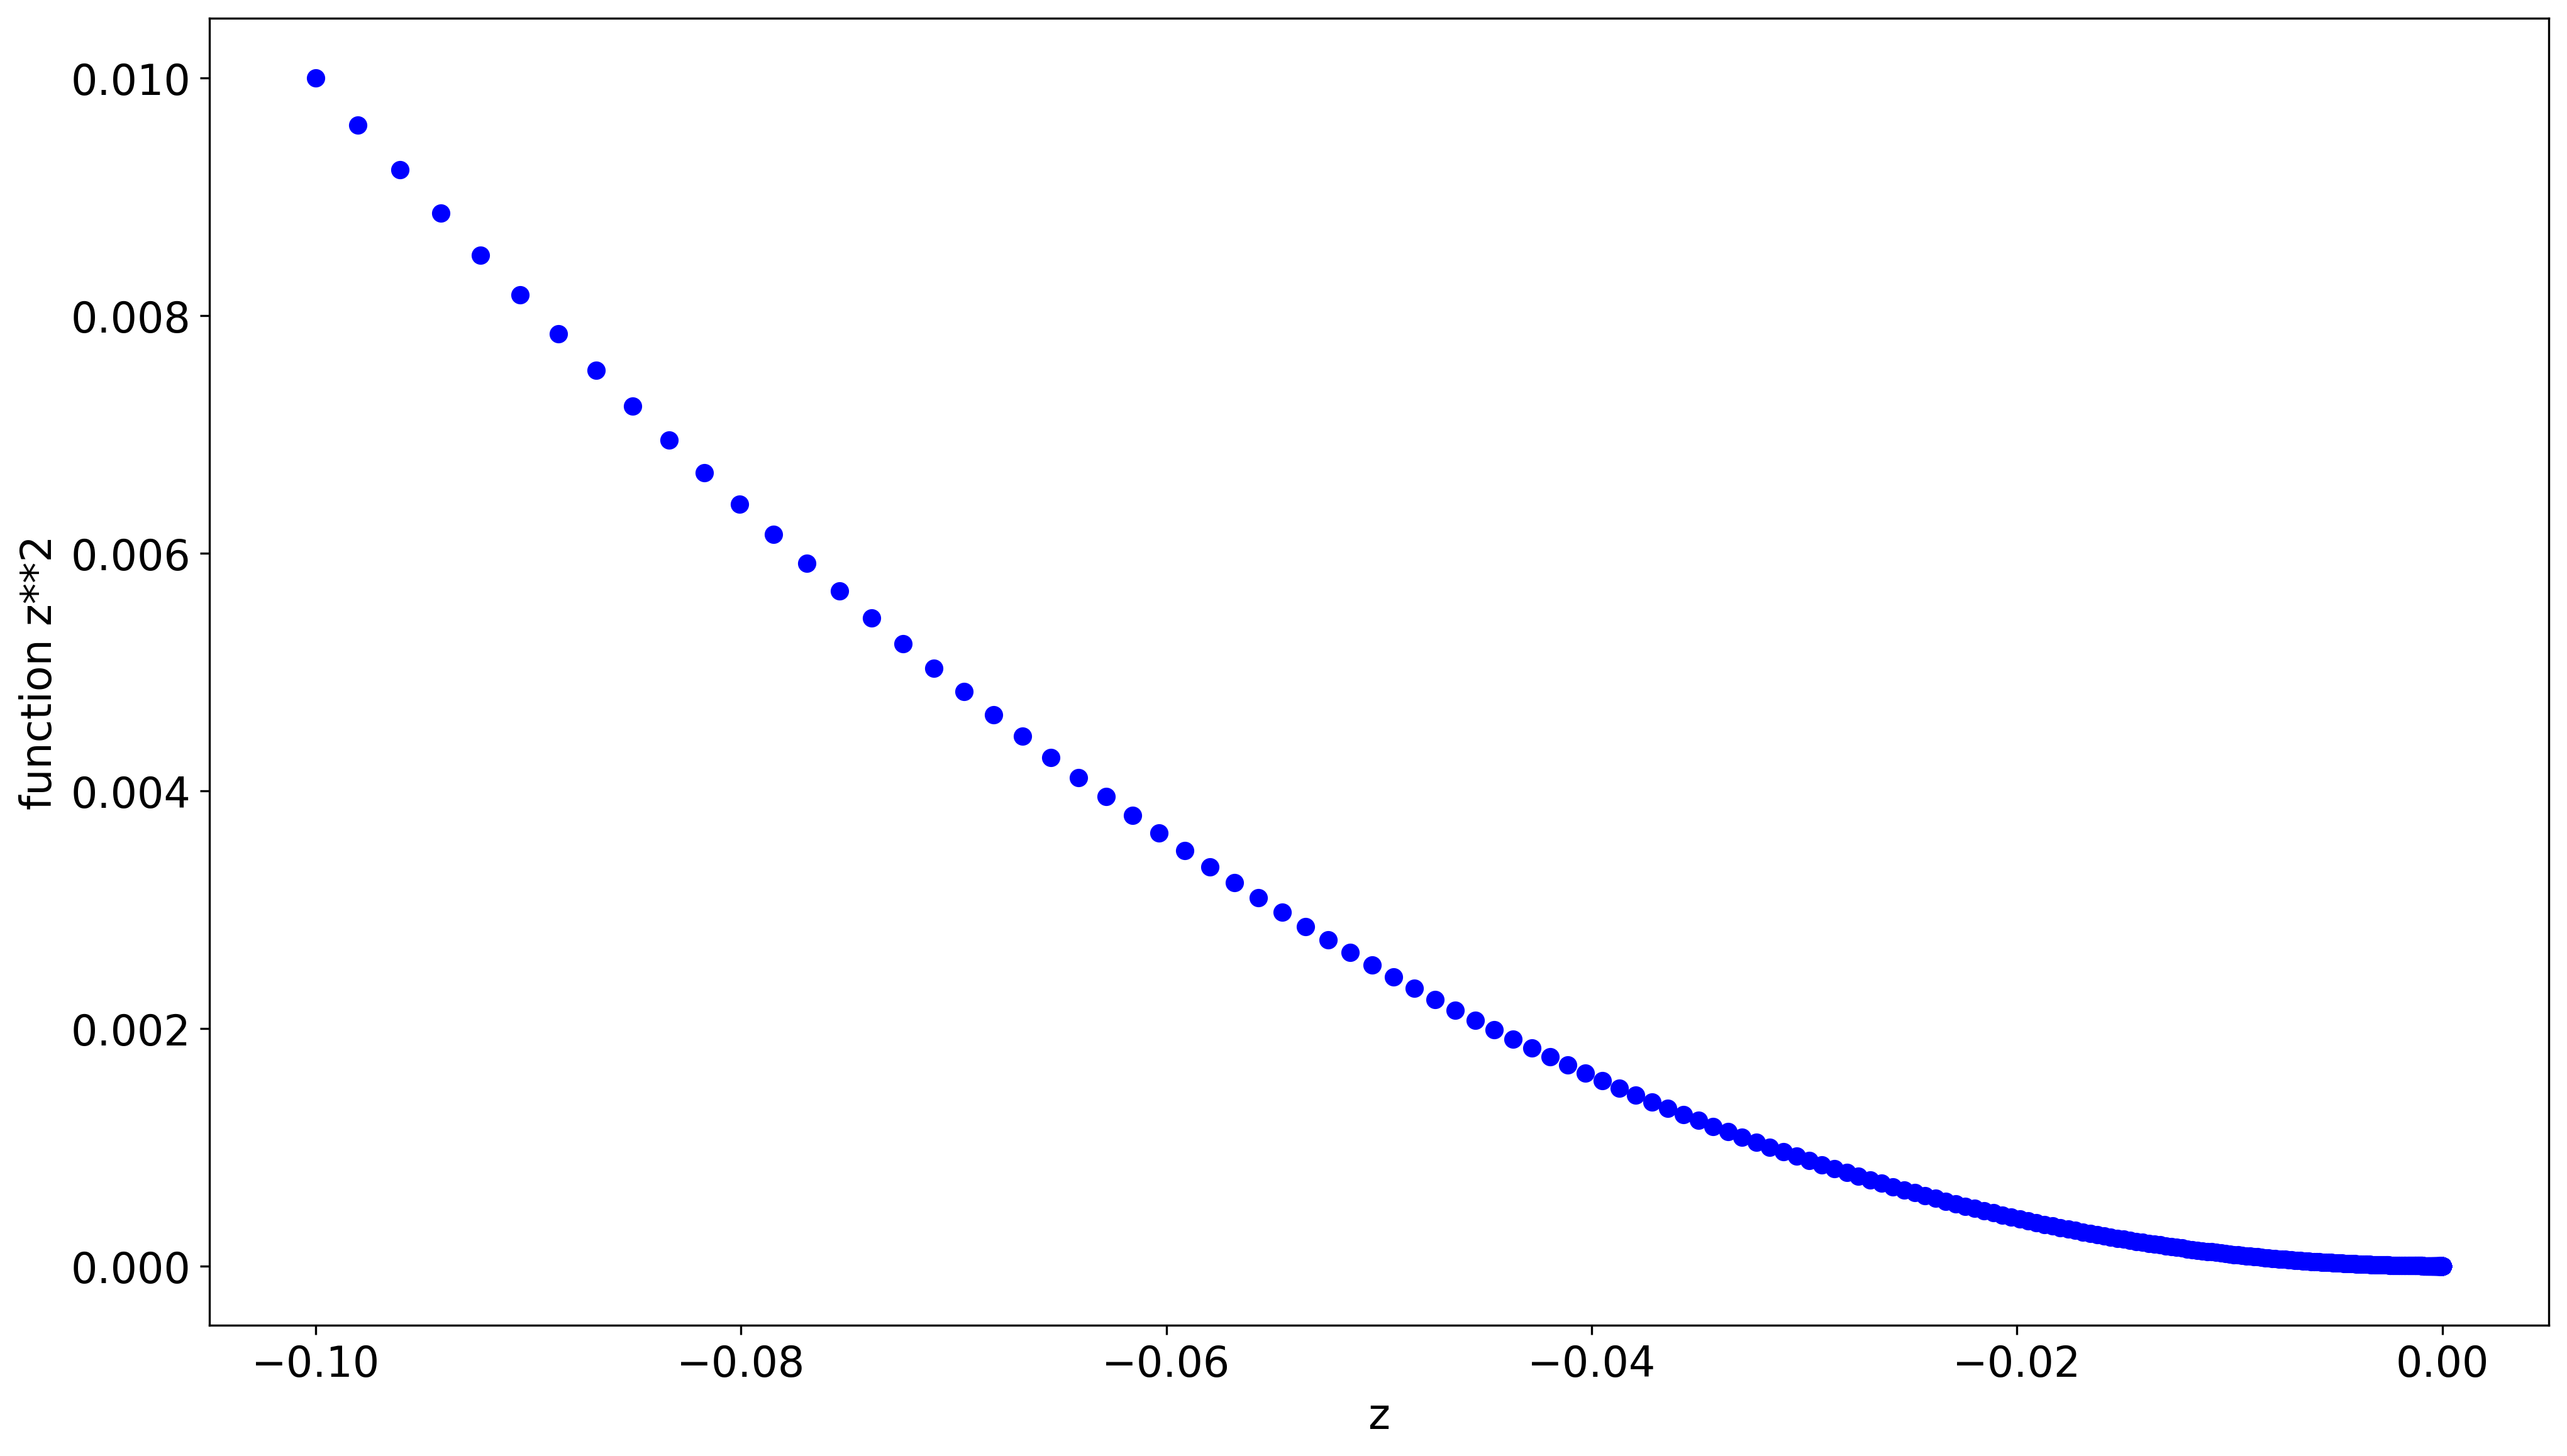

In [8]:
def fun(z):
    return z**2

def deriv_fun(z):
    return 2 * z

lr = 0.01
z_s = -0.1
for i in range(0,1000):
    d_f = deriv_fun(z_s)
    f = fun(z_s)
    plt.xlabel('z')
    plt.ylabel('function z**2')
    plt.plot(z_s, f, color='blue', marker='o')
    z_s = z_s - lr * d_f

print('z:', z_s)
print('function:', f)
print('derivative:', d_f)

In [11]:
x = np.array([0.35, 0.80, 0.55, 1.10])
y = np.array([0.3, 0.55, 0.5, 0.85])

Text(0, 0.5, 'LGD')

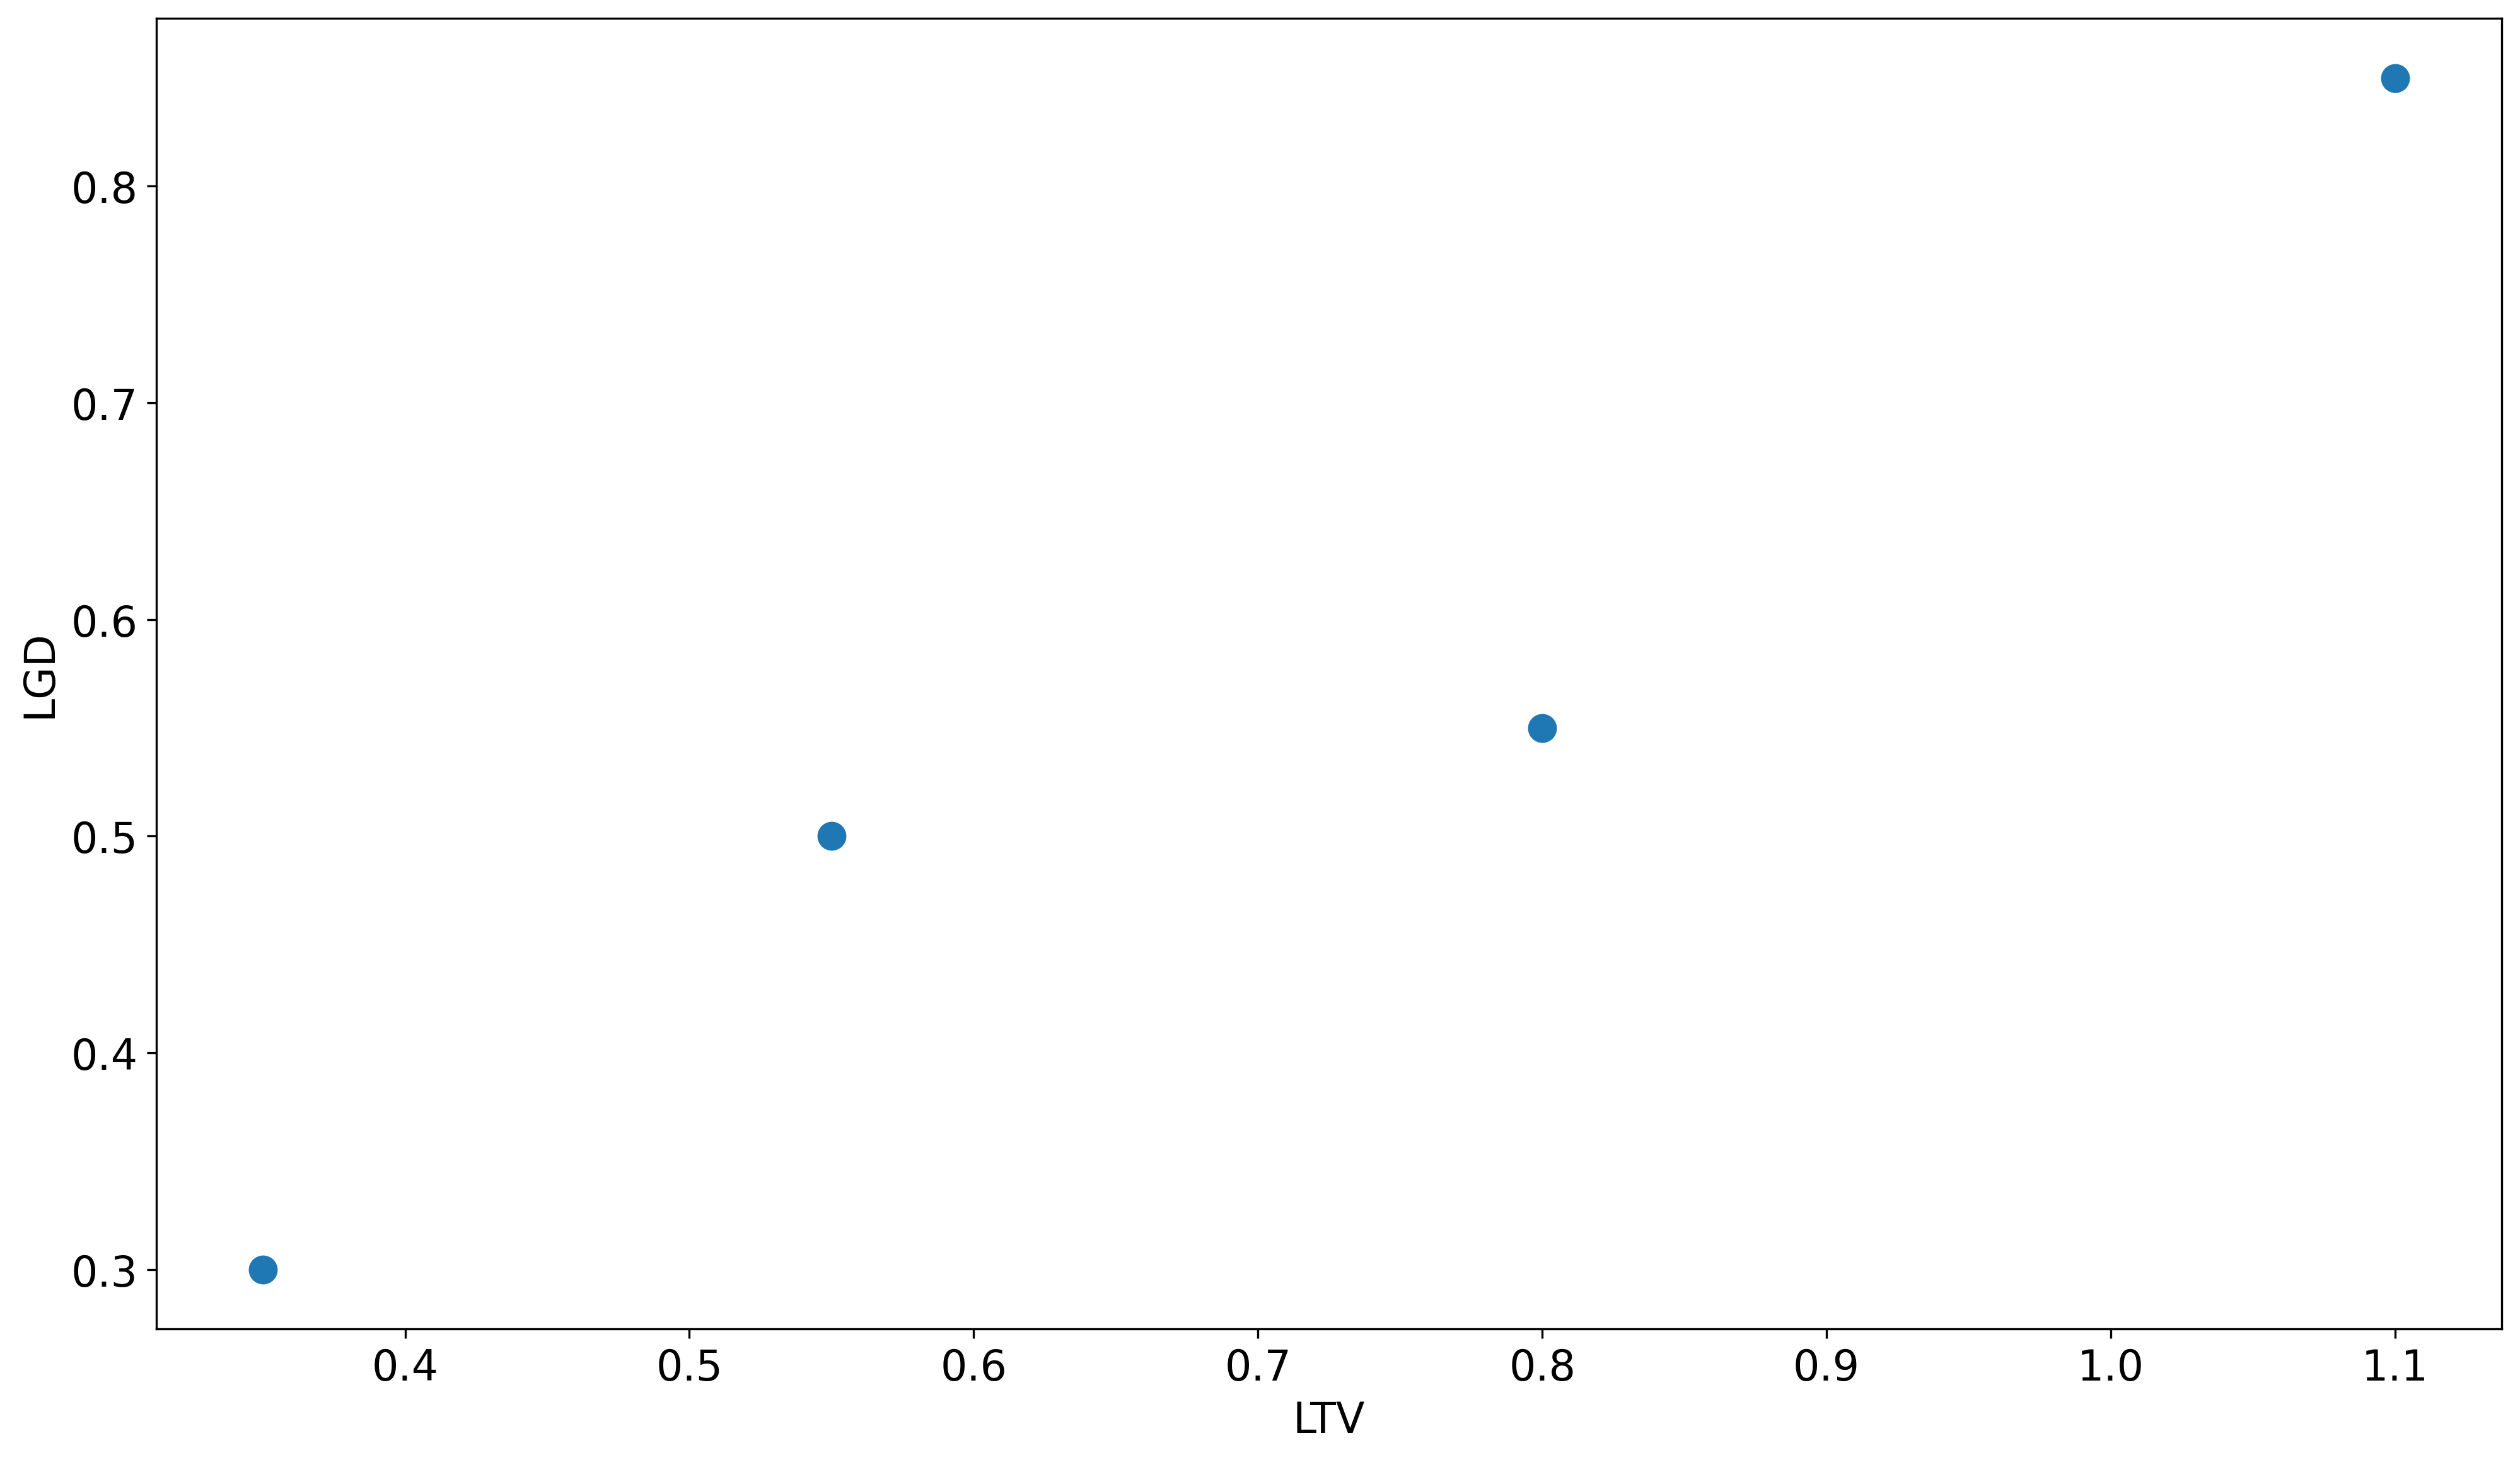

In [12]:
plt.scatter(x, y, marker='o', s=100)
plt.xlabel('LTV')
plt.ylabel('LGD')

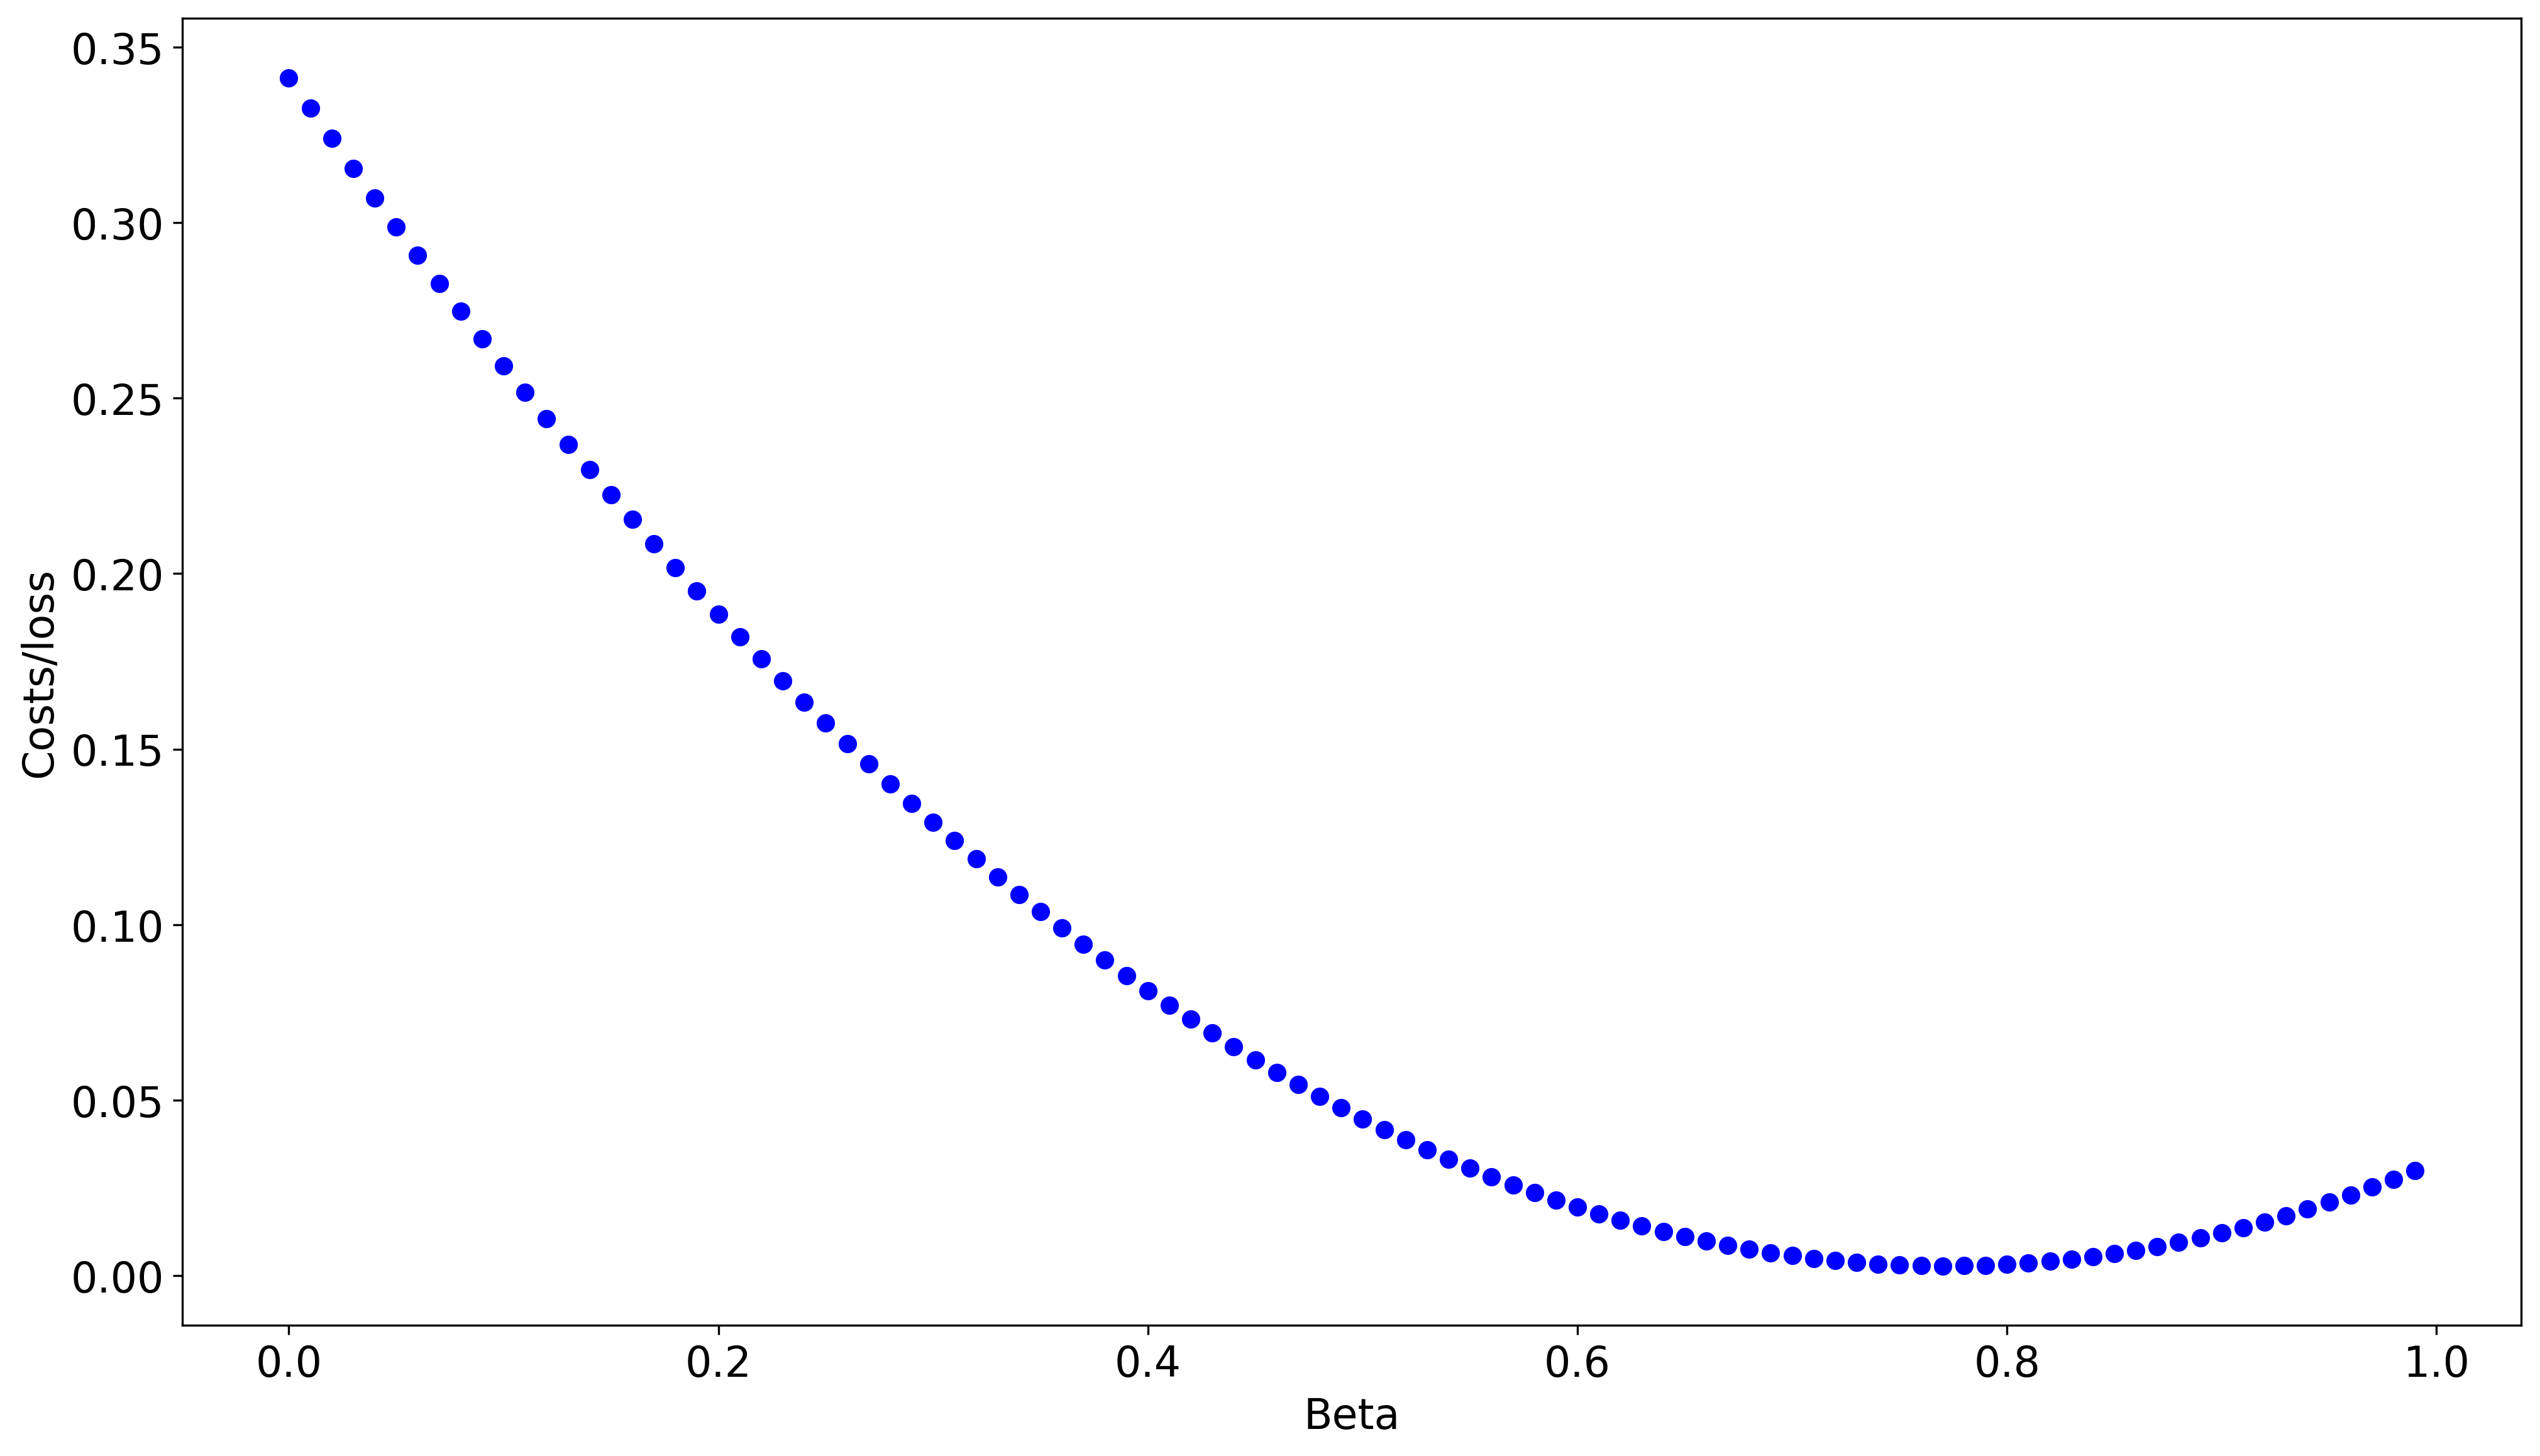

In [13]:
def J_cost_fun(beta):  
    y_pred = beta * x  
    costs = (y-y_pred)**2  
    cost = np.mean(costs)  
    return cost

for beta_s in range(0, 100, 1):  
    cost_beta = J_cost_fun(beta_s/100)  
    plt.xlabel('Beta')  
    plt.ylabel('Costs/loss')  
    plt.plot(beta_s/100, cost_beta, color='blue', marker='o') 


Solution for beta: 0.77


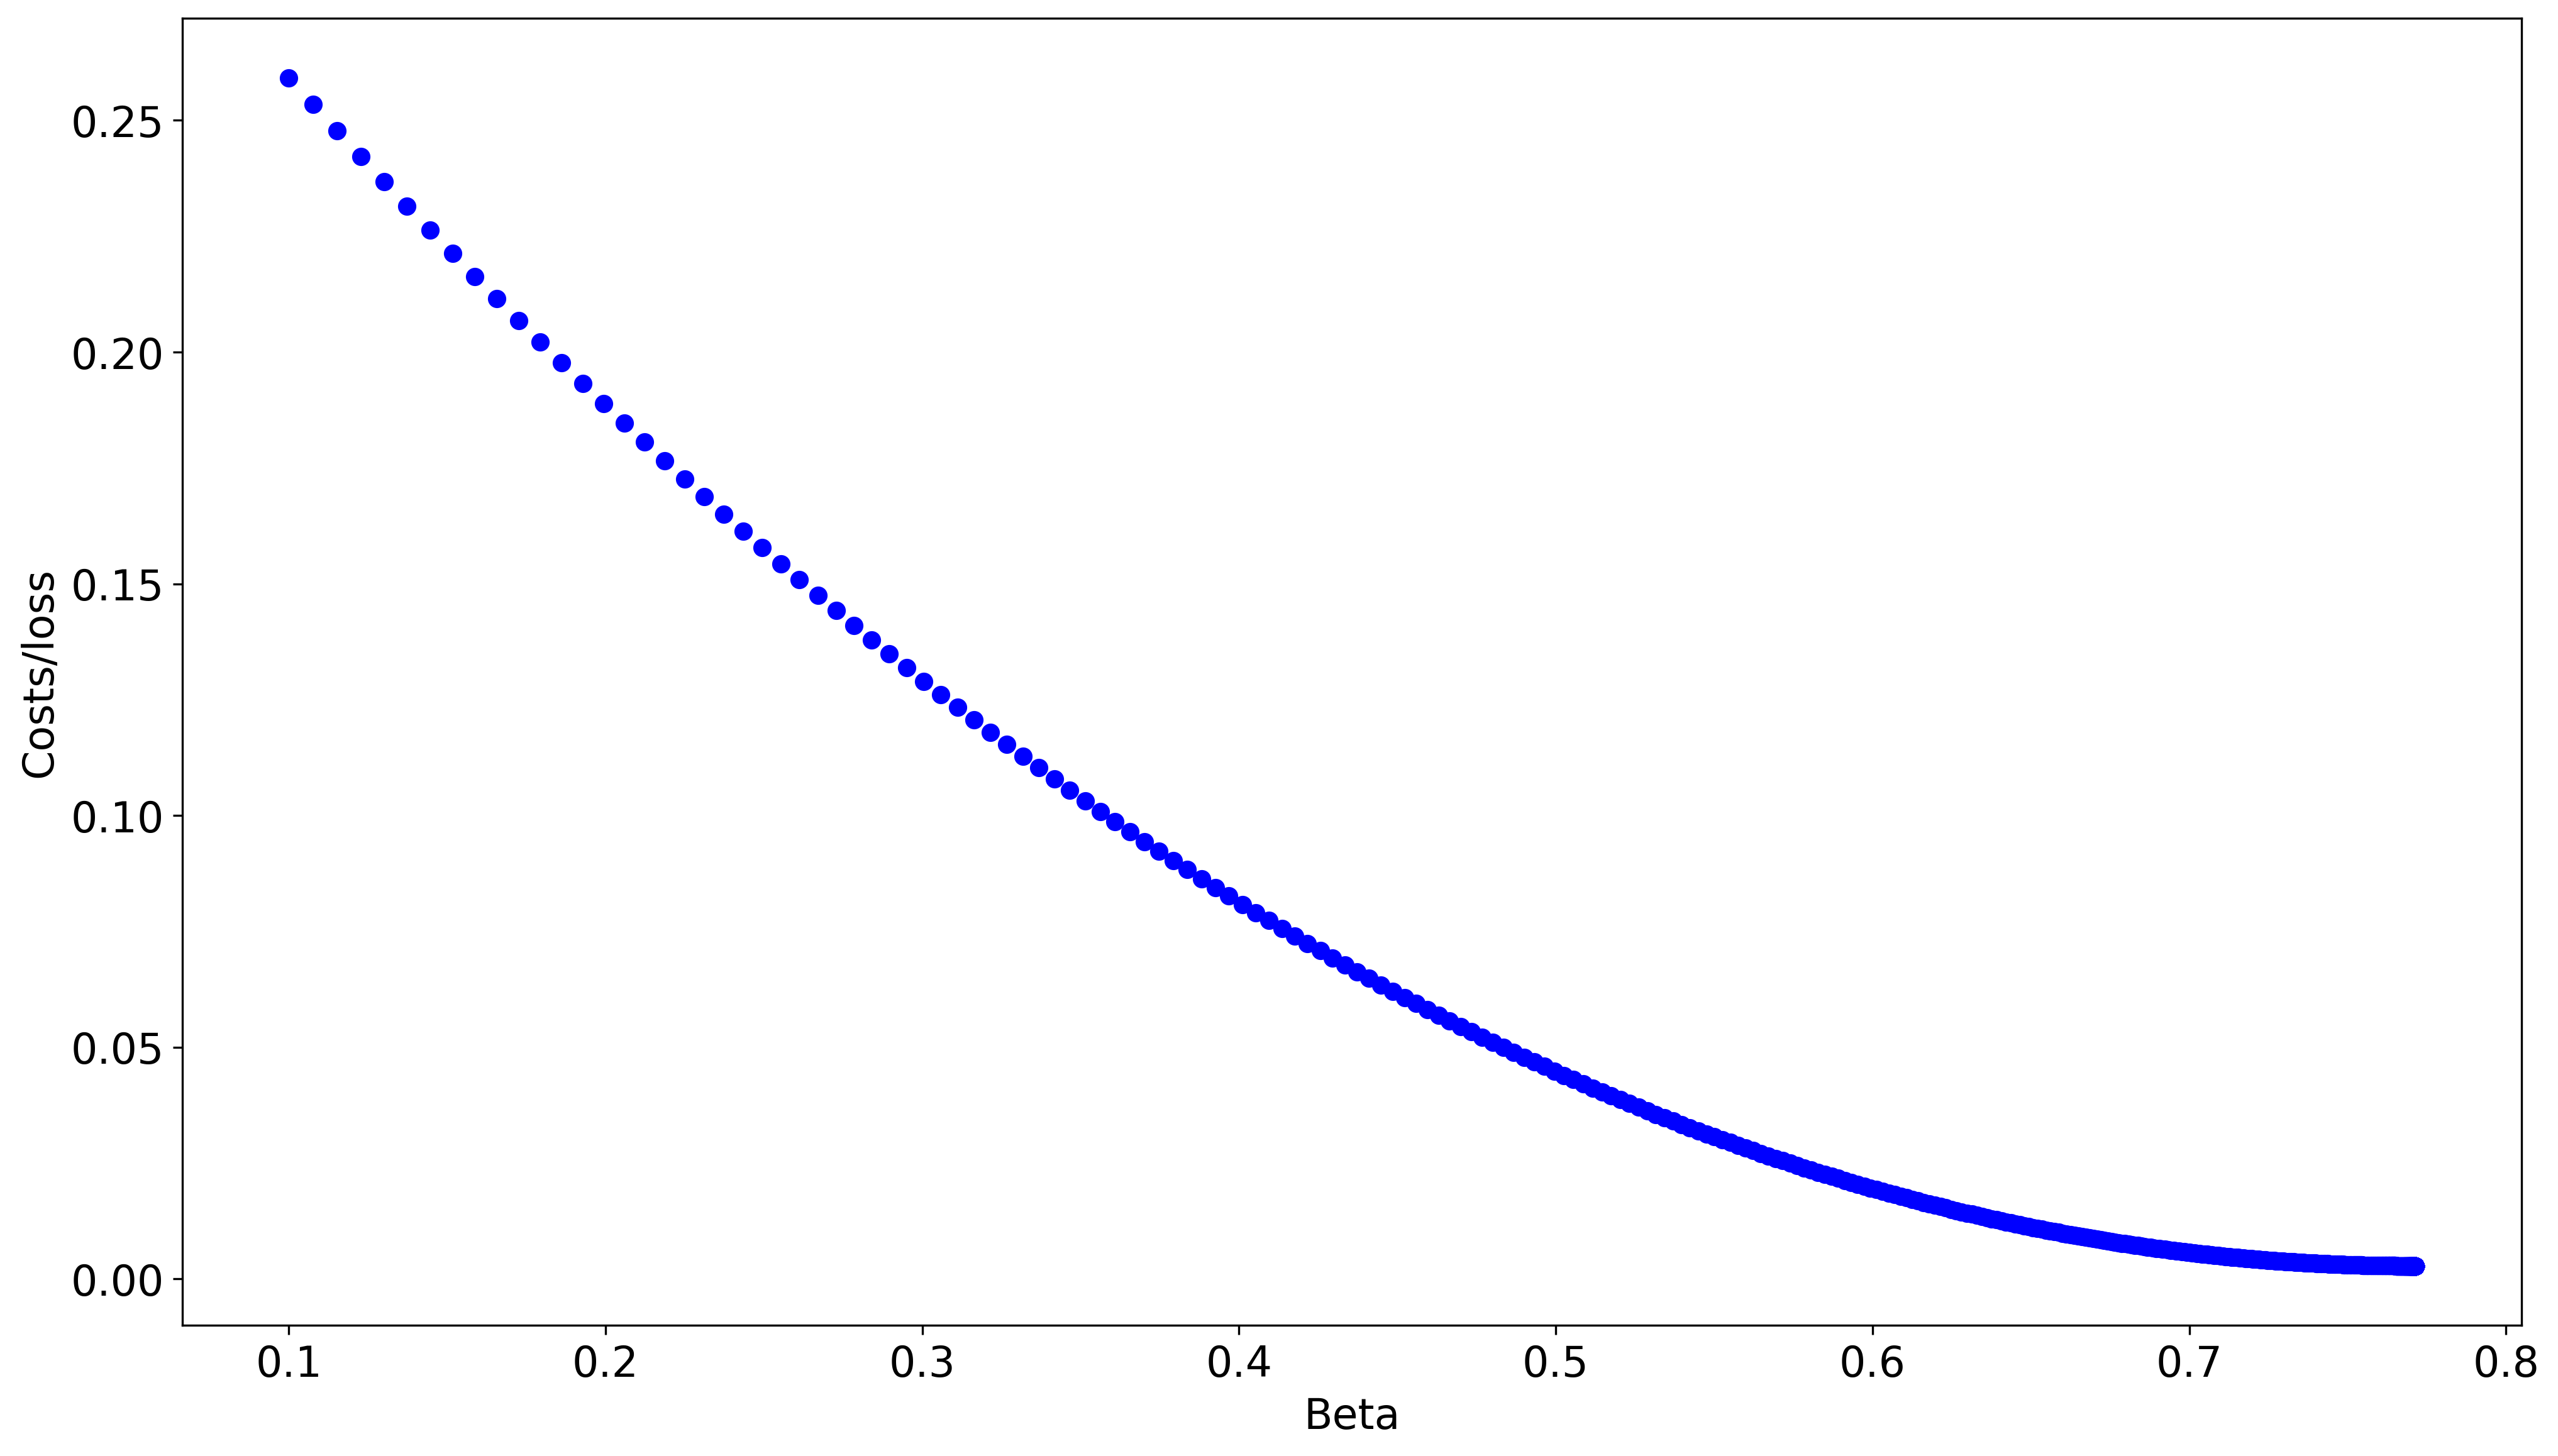

In [14]:
def J_deriv(beta):  
    y_pred = beta * x  
    tmp = np.mean(-2 * x * (y - y_pred))  
    return tmp  

lr = 0.01  
beta_s = 0.1  

for i in range(0,1000):  
    d_beta = J_deriv(beta_s)  
    cost = J_cost_fun(beta_s)  
    plt.xlabel('Beta')  
    plt.ylabel('Costs/loss')  
    plt.plot(beta_s, cost,color='blue', marker='o')
    beta_s = beta_s - lr * d_beta  
    
print('Solution for beta:', np.round(beta_s,2)) 

In [15]:
model = sm.OLS(y,x)  
results = model.fit()  
print('Solution for beta:', np.round(results.params,2))

Solution for beta: [0.77]
